In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
nav["nav_date"] = pd.to_datetime(nav["nav_date"])

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("NAV rows:", len(nav))
print("Benchmark rows:", len(benchmark))

NAV rows: 46000
Benchmark rows: 8050


In [2]:
nav = nav.sort_values(["amfi_code", "nav_date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [3]:
def calc_cagr(df, years):
    cutoff = df["nav_date"].max() - pd.DateOffset(years=years)
    period = df[df["nav_date"] >= cutoff].sort_values("nav_date")
    if len(period) < 2:
        return np.nan
    nav_start = period["nav"].iloc[0]
    nav_end = period["nav"].iloc[-1]
    n_years = (period["nav_date"].iloc[-1] - period["nav_date"].iloc[0]).days / 365.25
    if n_years == 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_results = []
for code in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == code]
    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": calc_cagr(fund_nav, 1),
        "cagr_3yr": calc_cagr(fund_nav, 3),
        "cagr_5yr": calc_cagr(fund_nav, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)
cagr_df.sort_values("cagr_3yr", ascending=False).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
16,119094,0.222779,0.351025,0.282144,Axis Midcap Fund - Regular - Growth
34,148567,0.203760,0.339920,0.309741,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,0.130738,0.324789,0.232951,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,0.532772,0.324340,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,0.296277,0.317692,0.328274,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.604893,0.304486,0.258047,SBI Bluechip Fund - Regular Plan - Growth
30,120843,0.266776,0.295751,0.309075,Kotak Flexicap Fund - Regular - Growth
36,148569,0.397838,0.291714,0.319495,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,0.479638,0.289602,0.235384,ABSL Frontline Equity Fund - Regular - Growth
39,149324,0.651955,0.269935,0.322874,DSP Small Cap Fund - Regular - Growth


In [4]:
Rf = 0.065  # 6.5% risk-free rate

sharpe_results = []
for code in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code]["daily_return"].dropna()
    if len(returns) < 2:
        continue
    ann_return = returns.mean() * 252
    ann_std = returns.std() * np.sqrt(252)
    sharpe = (ann_return - Rf) / ann_std if ann_std != 0 else np.nan
    sharpe_results.append({"amfi_code": code, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.sort_values("sharpe_ratio", ascending=False).head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [5]:
sortino_results = []
for code in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code]["daily_return"].dropna()
    if len(returns) < 2:
        continue
    ann_return = returns.mean() * 252
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else np.nan
    sortino = (ann_return - Rf) / downside_std if downside_std and downside_std != 0 else np.nan
    sortino_results.append({"amfi_code": code, "sortino_ratio": sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df.sort_values("sortino_ratio", ascending=False).head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [6]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta_results = []
for code in nav["amfi_code"].unique():
    fund_returns = nav[nav["amfi_code"] == code][["nav_date", "daily_return"]].dropna()
    merged = fund_returns.merge(nifty100[["date", "benchmark_return"]], left_on="nav_date", right_on="date").dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged["benchmark_return"], merged["daily_return"])
    alpha_beta_results.append({
        "amfi_code": code,
        "alpha": intercept * 252,
        "beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)
alpha_beta_df.sort_values("alpha", ascending=False).head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


In [7]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [8]:
mdd_results = []
for code in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == code].sort_values("nav_date").reset_index(drop=True)
    running_max = fund_nav["nav"].cummax()
    drawdown = fund_nav["nav"] / running_max - 1
    trough_idx = drawdown.idxmin()
    trough_date = fund_nav["nav_date"].iloc[trough_idx]
    # peak = last date before trough where NAV hit the running max
    peak_idx = fund_nav["nav"][:trough_idx + 1].idxmax()
    peak_date = fund_nav["nav_date"].iloc[peak_idx]
    mdd_results.append({
        "amfi_code": code,
        "max_drawdown": drawdown.min(),
        "peak_date": peak_date,
        "trough_date": trough_date,
    })

mdd_df = pd.DataFrame(mdd_results)
mdd_df.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown,peak_date,trough_date
22,119599,-0.525742,2023-01-17,2025-10-28
17,119095,-0.516778,2025-05-22,2026-05-11
4,101207,-0.354469,2024-11-21,2026-05-11
39,149324,-0.311719,2024-05-03,2025-01-03
21,119598,-0.287060,2024-08-28,2025-05-14
7,102886,-0.280011,2025-01-07,2026-04-27
0,100016,-0.247344,2022-03-30,2022-09-15
29,120842,-0.240035,2023-11-09,2024-10-17
11,118634,-0.233449,2025-04-09,2026-02-20
15,119093,-0.217514,2022-02-24,2023-05-22


In [9]:
scorecard = cagr_df[["amfi_code", "scheme_name", "cagr_3yr"]].merge(sharpe_df, on="amfi_code")
scorecard = scorecard.merge(sortino_df, on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(mdd_df[["amfi_code", "max_drawdown"]], on="amfi_code")
scorecard = scorecard.merge(fund_master[["amfi_code", "expense_ratio_pct"]], on="amfi_code")

scorecard["rank_return"] = scorecard["cagr_3yr"].rank(pct=True)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(pct=True)
scorecard["rank_alpha"] = scorecard["alpha"].rank(pct=True)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False)  # inverse: lower expense = better
scorecard["rank_mdd"] = scorecard["max_drawdown"].rank(pct=True)  # less negative = better = higher rank naturally

scorecard["score"] = (
    0.30 * scorecard["rank_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_mdd"]
) * 100

scorecard = scorecard.sort_values("score", ascending=False)
scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)
scorecard[["scheme_name", "score"]].head(10)

,scheme_name,score
34,Mirae Asset Large Cap Fund - Regular - Growth,86.2500
25,ICICI Pru Midcap Fund - Regular - Growth,82.2500
30,Kotak Flexicap Fund - Regular - Growth,82.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500
24,ICICI Pru Bluechip Fund - Direct - Growth,80.0000
16,Axis Midcap Fund - Regular - Growth,77.0000
19,SBI Bluechip Fund - Regular Plan - Growth,74.8125
36,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875
3,ABSL Frontline Equity Fund - Regular - Growth,68.1875
21,SBI Small Cap Fund - Regular Plan - Growth,67.3750


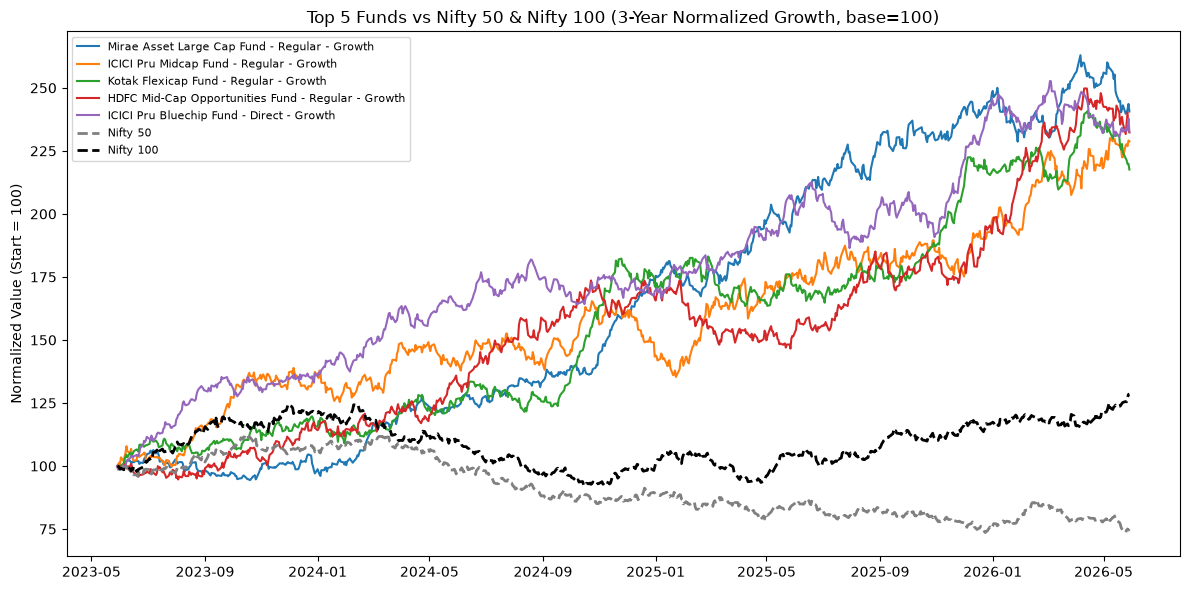

In [10]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

fig, ax = plt.subplots(figsize=(12, 6))
for code in top5_codes:
    fund_data = nav[nav["amfi_code"] == code].sort_values("nav_date")
    fund_data = fund_data[fund_data["nav_date"] >= fund_data["nav_date"].max() - pd.DateOffset(years=3)]
    normalized = fund_data["nav"] / fund_data["nav"].iloc[0] * 100
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    ax.plot(fund_data["nav_date"], normalized, label=scheme_name)

for idx_df, idx_label, color in [(nifty50, "Nifty 50", "gray"), (nifty100, "Nifty 100", "black")]:
    idx_recent = idx_df[idx_df["date"] >= idx_df["date"].max() - pd.DateOffset(years=3)]
    idx_normalized = idx_recent["close_value"] / idx_recent["close_value"].iloc[0] * 100
    ax.plot(idx_recent["date"], idx_normalized, label=idx_label, linestyle="--", color=color, linewidth=2)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year Normalized Growth, base=100)")
ax.set_ylabel("Normalized Value (Start = 100)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/10_benchmark_comparison.png", dpi=200)
plt.show()

In [11]:
# Tracking error = std(fund_return - benchmark_return) * sqrt(252), for top 5 funds
tracking_results = []
for code in top5_codes:
    fund_returns = nav[nav["amfi_code"] == code][["nav_date", "daily_return"]].dropna()
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    row = {"amfi_code": code, "scheme_name": scheme_name}
    for idx_df, idx_label in [(nifty50, "nifty50"), (nifty100, "nifty100")]:
        merged = fund_returns.merge(idx_df[["date", "benchmark_return"]], left_on="nav_date", right_on="date").dropna()
        row[f"tracking_error_{idx_label}"] = (merged["daily_return"] - merged["benchmark_return"]).std() * np.sqrt(252)
    tracking_results.append(row)

tracking_df = pd.DataFrame(tracking_results)
tracking_df

,amfi_code,scheme_name,tracking_error_nifty50,tracking_error_nifty100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.193996,0.189664
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.233124,0.231968
2,120843,Kotak Flexicap Fund - Regular - Growth,0.205148,0.206425
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.229755,0.228699
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.191376,0.191587
